In [1]:
import polars as pl
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from scipy import stats
import utils

TRANSFERS_FILE = "data/erc1155_transfers.parquet"

In [2]:
df = pl.read_parquet(TRANSFERS_FILE)
df = utils.filter_transfers(df)
tdf = df.explode(['token_ids', 'amounts'])
tdf.head()

address,transaction_index,log_index,transaction_hash,block_number,block_timestamp,type,operator,from,to,token_ids,amounts
str,i64,i64,str,i64,str,str,str,str,str,str,str
"""0xd0e4847359ae76c2786d242e5f45…",40,32,"""0x223600ba642f4dc6644e5eb4b0a0…",6930510,"""2018-12-22 04:21:31""","""SINGLE""","""0x6e8a8a0de641161b306cd548710c…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""32""","""100000000"""
"""0xd0e4847359ae76c2786d242e5f45…",53,64,"""0x1b839bfeb716c358f367787e77b9…",6930534,"""2018-12-22 04:28:13""","""SINGLE""","""0x6e8a8a0de641161b306cd548710c…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""32""","""20000000"""
"""0xd0e4847359ae76c2786d242e5f45…",87,48,"""0x7cf68091cfd5ca00ee9e85a49453…",6930550,"""2018-12-22 04:33:16""","""SINGLE""","""0x8ee1dae56bb5dbc071973618e562…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""19""","""2270967"""
"""0xd0e4847359ae76c2786d242e5f45…",87,52,"""0x7cf68091cfd5ca00ee9e85a49453…",6930550,"""2018-12-22 04:33:16""","""SINGLE""","""0x8ee1dae56bb5dbc071973618e562…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""32""","""10000000"""
"""0xd0e4847359ae76c2786d242e5f45…",108,57,"""0xb1621b9c77d881ae013cf987cb03…",6930586,"""2018-12-22 04:43:09""","""SINGLE""","""0x6e8a8a0de641161b306cd548710c…","""0x0000000000000000000000000000…","""0x463def03f98b328a75051ee5ebe9…","""32""","""20000000"""


In [3]:
block_timestamps = tdf.select('block_number', 'block_timestamp').unique().with_columns(
    block_timestamp=pl.col('block_timestamp').str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False)
)

single = tdf.filter(pl.col('type') == 'SINGLE')
batch = tdf.filter(pl.col('type') == 'BATCH')
single_count = single.group_by('block_number').len(name='num_single')
batch_count = batch.group_by('block_number').len(name='num_batch')
block_stats = single_count.join(batch_count, on='block_number', how='left').fill_null(0)
block_stats = block_stats.with_columns(num_transfers=pl.col('num_single') + pl.col('num_batch'))
block_stats = block_stats.join(block_timestamps, on='block_number', how='left')
block_stats = block_stats.sort('block_number')
block_stats

block_number,num_single,num_batch,num_transfers,block_timestamp
i64,u32,u32,u32,datetime[μs]
6930510,1,0,1,2018-12-22 04:21:31
6930534,1,0,1,2018-12-22 04:28:13
6930550,2,0,2,2018-12-22 04:33:16
6930586,2,0,2,2018-12-22 04:43:09
6930593,2,0,2,2018-12-22 04:44:57
…,…,…,…,…
21525882,14,0,14,2024-12-31 23:58:23
21525883,1,0,1,2024-12-31 23:58:35
21525886,1,0,1,2024-12-31 23:59:11


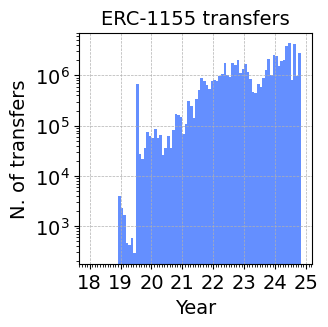

In [4]:
d1 = np.floor_divide(block_stats['block_timestamp'].cast(pl.Int64).to_numpy(), 1000000)
d2 = block_stats['num_transfers'].to_numpy()
hist_bins = [pd.Timestamp(y, m, 1).timestamp() for y in range(2018, 2025, 1) for m in range(1, 12+1, 1)]
plot_bins = [datetime.datetime(y, m, 1) for y in range(2018, 2025, 1) for m in range(1, 12+1, 1)]
s = stats.binned_statistic(d1, d2, statistic='sum', bins=hist_bins)

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot()
ax.set_title('ERC-1155 transfers')
ax.set_xlabel('Year')
ax.set_ylabel('N. of transfers')
ax.set_yscale('log')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator(12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.stairs(s.statistic[:-1], plot_bins[:-1], color='#648fff', fill=True)
ax.grid(linestyle='--', linewidth=0.5)
utils.set_font_size(ax, 14)
plt.savefig("figures/temporal-transfers.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [6]:
x = tdf.filter((pl.col("block_timestamp") >= "2019-07-01") & (pl.col("block_timestamp") <= "2019-07-31"))
data = x.group_by('address').len(name='num_transfer').sort(by='num_transfer')
total_transfers = 0
for r in data.iter_rows(named=True):
    address = r['address']
    num_transfer = r['num_transfer']
    total_transfers += num_transfer
    print(f'{address}\t{num_transfer}')
print(f'Total:\t{total_transfers}')

0x72353f8968f1a50479cab7c74076b48eb358a2e3	5
0x5b306b1d0f1c1959777469a3fd42557298e9193a	14
0xd0e4847359ae76c2786d242e5f45c4f6f1abd752	18
0xf64c866b5b4f25c1d17e3a7cea883c367f460f91	20
0xd6fbc588964e5a3d5caa56b69205ad1adbe9f438	26
0xa2a295ae156bcd0023783cc2666ccbb0ca218d9f	56
0x559604845ffc64a05f780ead75249c377b1dae57	277
0x2b1870752208935fda32ab6a016c01a27877cf12	150680
0xfaafdc07907ff5120a76b34b731b278c38d6043c	542349
Total:	693445


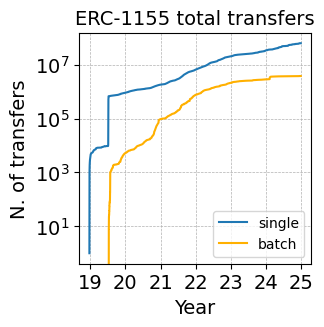

In [7]:
x = block_stats['block_timestamp'].cast(pl.Datetime).to_numpy()
y_s = np.cumsum(block_stats['num_single'].to_numpy())
y_b = np.cumsum(block_stats['num_batch'].to_numpy())

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot()
ax.set_title('ERC-1155 total transfers')
ax.set_xlabel('Year')
ax.set_ylabel('N. of transfers')
ax.set_yscale('log')
ax.plot(x, y_s, color='#1f78b4', label='single')
ax.plot(x, y_b, color='#ffb000', label='batch')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.grid(linestyle='--', linewidth=0.5)
ax.legend(loc='lower right')
utils.set_font_size(ax, 14)
plt.savefig("figures/temporal-transfers-type.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [8]:
block_timestamps = tdf.select('block_number', 'block_timestamp').unique().with_columns(
    block_timestamp=pl.col('block_timestamp').str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False)
)

active_contracts = pl.read_csv('results/active_contracts.tsv', separator='\t', has_header=True).rename({'block_id':'block_number'})
active_contracts = active_contracts.join(block_timestamps, on='block_number', how='left')
active_contracts = active_contracts.sort('block_number')
active_contracts

block_number,num_active_contracts,block_timestamp
i64,i64,datetime[μs]
6930510,1,2018-12-22 04:21:31
6930534,1,2018-12-22 04:28:13
6930550,1,2018-12-22 04:33:16
6930586,1,2018-12-22 04:43:09
6930593,1,2018-12-22 04:44:57
…,…,…
21525882,78526,2024-12-31 23:58:23
21525883,78526,2024-12-31 23:58:35
21525886,78526,2024-12-31 23:59:11


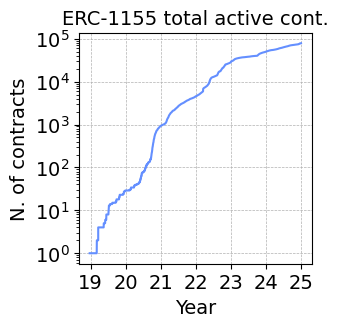

In [9]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-1155 total active cont.')
ax.set_xlabel('Year')
ax.set_ylabel('N. of contracts')
ax.set_yscale('log')
ax.plot(active_contracts['block_timestamp'], active_contracts['num_active_contracts'], color='#648fff')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.grid(which='major', linestyle='--', linewidth=0.5)
#ax.set_xlim([xmin, xmax])
utils.set_font_size(ax, 14)
plt.savefig("figures/temporal-active-contracts.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [10]:
block_timestamps = tdf.select('block_number', 'block_timestamp').unique().with_columns(
    block_timestamp=pl.col('block_timestamp').str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False)
)

active_tokens = pl.read_csv('results/active_tokens.tsv', separator='\t', has_header=True).rename({'block_id':'block_number'})
active_tokens = active_tokens.join(block_timestamps, on='block_number', how='left')
active_tokens = active_tokens.sort('block_number')
active_tokens

block_number,num_active_tokens,block_timestamp
i64,i64,datetime[μs]
6930510,1,2018-12-22 04:21:31
6930534,1,2018-12-22 04:28:13
6930550,2,2018-12-22 04:33:16
6930586,2,2018-12-22 04:43:09
6930593,3,2018-12-22 04:44:57
…,…,…
21525882,8680311,2024-12-31 23:58:23
21525883,8680311,2024-12-31 23:58:35
21525886,8680311,2024-12-31 23:59:11


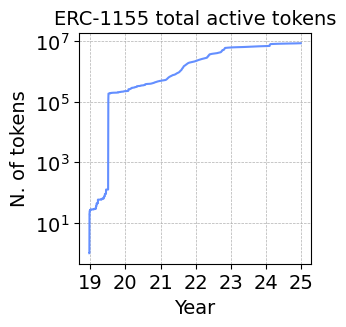

In [11]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-1155 total active tokens')
ax.set_xlabel('Year')
ax.set_ylabel('N. of tokens')
ax.set_yscale('log')
ax.plot(active_tokens['block_timestamp'], active_tokens['num_active_tokens'], color='#648fff')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.grid(which='major', linestyle='--', linewidth=0.5)
#ax.set_xlim([xmin, xmax])
utils.set_font_size(ax, 14)
plt.savefig("figures/temporal-active-tokens.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Analysis of token transfer volume over time

We compare the volume of ERC-1155 transfers with that of ERC-20 and ERC-721 transfers. The data is aggregated by block, i.e., for each block we count the number of transfers of each type.

In [ ]:
erc_20_721_stats = pl.read_csv("data/erc20-721_stats.tsv", separator='\t', try_parse_dates=True)
full_stats = erc_20_721_stats.join(
    block_stats.select("block_number", "block_timestamp", "num_transfers").rename({"num_transfers":"erc1155_transfers"}), 
    on=["block_number", "block_timestamp"], 
    how="full", coalesce=True).sort(by="block_number").fill_null(0)
full_stats

In [5]:
binned_stats = full_stats.group_by_dynamic("block_timestamp", every="1w", closed="right").agg(pl.col("erc20_transfers").sum(), pl.col("erc721_transfers").sum(), pl.col("erc1155_transfers").sum()).sort("block_timestamp")
binned_stats

block_timestamp,erc20_transfers,erc721_transfers,erc1155_transfers
datetime[μs],i64,i64,u32
2015-10-26 00:00:00,3,0,0
2015-11-02 00:00:00,79,0,0
2015-11-09 00:00:00,118,0,0
2015-11-16 00:00:00,5,0,0
2015-11-23 00:00:00,6,0,0
…,…,…,…
2024-12-02 00:00:00,9923819,171212,624381
2024-12-09 00:00:00,9397021,246218,1602523
2024-12-16 00:00:00,9330273,274744,871412


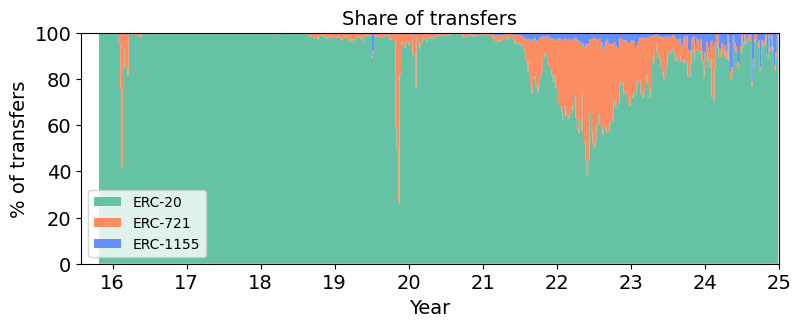

In [ ]:
transfers_sum = binned_stats['erc20_transfers'] + binned_stats['erc721_transfers'] + binned_stats['erc1155_transfers']
dates = binned_stats['block_timestamp']
erc20_perc = binned_stats['erc20_transfers'] * 100 / transfers_sum
erc721_perc = binned_stats['erc721_transfers'] * 100 / transfers_sum
erc1155_perc = binned_stats['erc1155_transfers'] * 100 / transfers_sum
fig, ax = plt.subplots(figsize=(9, 3))
ax.set_title('Share of transfers')
ax.set_xlabel('Year')
ax.set_ylabel('% of transfers')
ax.stackplot(dates, erc20_perc, erc721_perc, erc1155_perc,
             colors=['#66c2a5', '#fc8d62', '#648fff'],
             labels=['ERC-20', 'ERC-721', 'ERC-1155'], 
             step='post')
ax.margins(0,0)
ax.set_xlim(left=datetime.datetime(2015, 7, 30, 0, 0), right=datetime.datetime(2024, 12, 31, 0, 0))
ax.legend(loc='lower left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
utils.set_font_size(ax, 14)
plt.savefig("figures/temporal-standard-shares.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
dates = binned_stats['block_timestamp']
erc20_cumul = np.cumsum(binned_stats['erc20_transfers'])
erc721_cumul = np.cumsum(binned_stats['erc721_transfers'])
erc1155_cumul = np.cumsum(binned_stats['erc1155_transfers'])

fig, ax = plt.subplots(figsize=(9, 3))
ax.set_title('Total transfers')
ax.set_xlabel('Year')
ax.set_ylabel('N. of transfers')
ax.set_yscale('log')
ax.plot(dates, erc20_cumul, color='#66c2a5', label='ERC-20')
ax.plot(dates, erc721_cumul, color='#fc8d62', label='ERC-721')
ax.plot(dates, erc1155_cumul, color='#648fff', label='ERC-1155')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.set_xlim(left=datetime.datetime(2015, 7, 30, 0, 0), right=datetime.datetime(2024, 12, 31, 0, 0))
ax.legend()
utils.set_font_size(ax, 14)
plt.savefig("figures/temporal-standard-cumul.pdf", format='pdf', bbox_inches='tight')
plt.show()